In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

industry = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

In [3]:
print("All datasets loaded successfully!")

print(fund_master.shape)
print(nav_history.shape)
print(performance.shape)
print(transactions.shape)
print(portfolio.shape)

All datasets loaded successfully!
(40, 15)
(46000, 3)
(40, 19)
(32778, 13)
(322, 8)


In [4]:
print(nav_history.columns.tolist())

print(transactions.columns.tolist())

print(portfolio.columns.tolist())

['amfi_code', 'date', 'nav']
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [5]:
# Historical VaR (95%) & CVaR

# Sort data
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Daily returns
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first NaN return for each fund
returns = nav_history.dropna(subset=["daily_return"])

# Calculate VaR & CVaR
risk_metrics = []

for amfi, group in returns.groupby("amfi_code"):
    var95 = np.percentile(group["daily_return"], 5)
    cvar95 = group[group["daily_return"] <= var95]["daily_return"].mean()

    risk_metrics.append({
        "amfi_code": amfi,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar_report = pd.DataFrame(risk_metrics)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv generated successfully!")

var_cvar_report.csv generated successfully!


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Convert date
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort values
nav_history = nav_history.sort_values(["amfi_code", "date"])

# Daily returns
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Rolling Sharpe
nav_history["rolling_sharpe"] = (
    nav_history.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

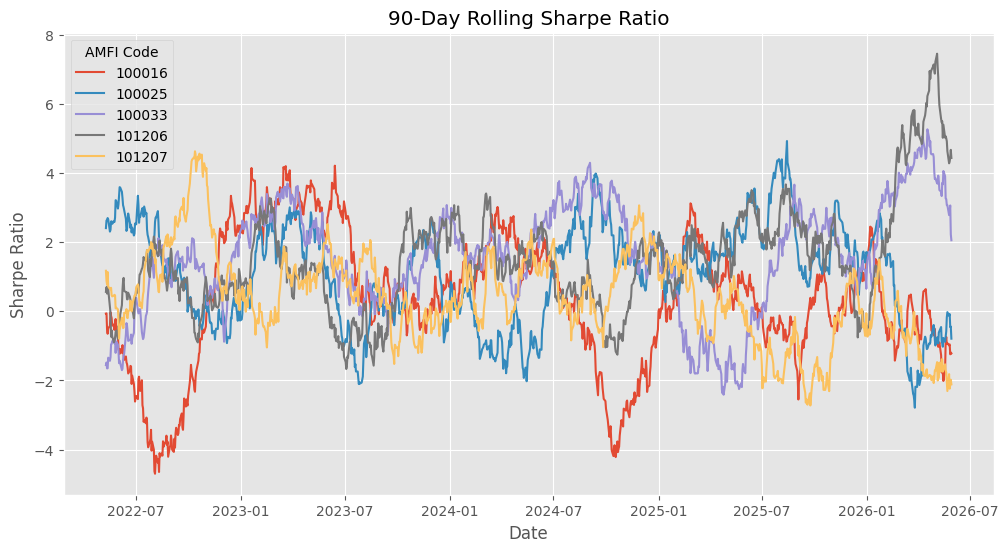

In [8]:
# Select first 5 funds
top5 = nav_history["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:
    df = nav_history[nav_history["amfi_code"] == fund]

    plt.plot(
        df["date"],
        df["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# -----------------------------
# Investor Cohort Analysis
# -----------------------------

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# First transaction year
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_txn.rename(
    columns={"transaction_date": "cohort_year"},
    inplace=True
)

transactions = transactions.merge(
    first_txn,
    on="investor_id"
)

cohort_analysis = (
    transactions
    .groupby("cohort_year")
    .agg(
        Investors=("investor_id","nunique"),
        Avg_SIP=("amount_inr","mean"),
        Total_Invested=("amount_inr","sum")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,Investors,Avg_SIP,Total_Invested
0,2024,4803,107422.541832,3491125187
1,2025,197,109158.577061,30455243


In [10]:
cohort_analysis.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("Investor Cohort Report Saved!")

Investor Cohort Report Saved!


In [11]:
# -----------------------------
# SIP Continuity Analysis
# -----------------------------

sip_txn = transactions.copy()

sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_continuity = (
    sip_txn.groupby("investor_id")
    .agg(
        SIP_Count=("transaction_date","count"),
        Avg_Gap_Days=("gap_days","mean")
    )
    .reset_index()
)

sip_continuity["Risk_Flag"] = np.where(
    (sip_continuity["SIP_Count"]>=6) &
    (sip_continuity["Avg_Gap_Days"]>35),
    "At Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,SIP_Count,Avg_Gap_Days,Risk_Flag
0,INV000001,3,38.000,Healthy
1,INV000002,6,82.800,At Risk
2,INV000003,2,238.000,Healthy
3,INV000004,9,53.375,At Risk
4,INV000005,8,52.000,At Risk


In [12]:
sip_continuity.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("SIP Continuity Report Saved!")

SIP Continuity Report Saved!


In [13]:
# -----------------------------
# Simple Fund Recommender
# -----------------------------

risk_choice = "Moderate"      # Change to Low / Moderate / High

if risk_choice == "Low":
    grades = ["Low"]

elif risk_choice == "Moderate":
    grades = ["Low", "Moderate"]

else:
    grades = ["Low", "Moderate", "High"]

recommendations = (
    performance[
        performance["risk_grade"].isin(grades)
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

recommendations = recommendations[
    [
        "scheme_name",
        "fund_house",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct"
    ]
]

recommendations

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14


In [14]:
recommendations.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

print("Fund Recommendation Report Saved!")

Fund Recommendation Report Saved!


In [15]:
# -----------------------------
# Sector HHI
# -----------------------------

portfolio["weight_pct"] = portfolio["weight_pct"] / 100

hhi = (
    portfolio
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi["Portfolio_Type"] = np.where(
    hhi["HHI"] > 0.18,
    "Highly Concentrated",
    "Diversified"
)

hhi.head()

,amfi_code,HHI,Portfolio_Type
0,100016,0.139534,Diversified
1,100033,0.147592,Diversified
2,101206,0.129332,Diversified
3,101207,0.200700,Highly Concentrated
4,102885,0.174709,Diversified


In [16]:
hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI Report Saved!")

HHI Report Saved!


# Advanced Analytics Insights

## Key Findings

1. Historical VaR and CVaR identify the funds with the highest downside risk.

2. Rolling 90-Day Sharpe Ratio highlights how fund performance changes over time.

3. Investors from earlier cohorts contributed the highest cumulative investment.

4. Investors with an average SIP gap greater than 35 days are classified as "At Risk".

5. Highly concentrated portfolios (High HHI) may carry higher sector-specific risk compared to diversified portfolios.